In [1]:
# Train baseline models
from pathlib import Path
import sys, os

repo_root = os.path.abspath("..")
if repo_root not in sys.path:
    sys.path.append(repo_root)

from src.modeling_lgbm import run_lgbm_models

ROOT = Path("..").resolve()
DATA_TRAIN = ROOT / "data" / "processed" / "training_fe_full.csv"
DATA_TEST = ROOT / "data" / "processed" / "test_fe_full.csv"
DATA_LABELS = ROOT / "data" / "raw" / "training_set_labels.csv"
ARTIFACTS = ROOT / "artifacts_lgbm"

results_lgbm = run_lgbm_models(
    train_features_path=str(DATA_TRAIN),
    test_features_path=str(DATA_TEST),
    train_labels_path=str(DATA_LABELS),
    n_splits=5,
    out_dir=str(ARTIFACTS),
)


=== Training model for h1n1_vaccine ===
Running fold 1/5 for h1n1_vaccine...
Running fold 2/5 for h1n1_vaccine...
Running fold 3/5 for h1n1_vaccine...
Running fold 4/5 for h1n1_vaccine...
Running fold 5/5 for h1n1_vaccine...
h1n1_vaccine CV results: accuracy=0.857, precision=0.738, recall=0.510, f1=0.603, roc_auc=0.870
Saved confusion matrices for h1n1_vaccine:
  Raw        → C:\Projects\Redi\NeuroShot_v.2\neuro_flushot\artifacts_lgbm\confusion_matrix_h1n1_vaccine.png
  Normalized → C:\Projects\Redi\NeuroShot_v.2\neuro_flushot\artifacts_lgbm\confusion_matrix_h1n1_vaccine_normalized.png

=== Training model for seasonal_vaccine ===
Running fold 1/5 for seasonal_vaccine...
Running fold 2/5 for seasonal_vaccine...
Running fold 3/5 for seasonal_vaccine...
Running fold 4/5 for seasonal_vaccine...
Running fold 5/5 for seasonal_vaccine...
seasonal_vaccine CV results: accuracy=0.788, precision=0.780, recall=0.759, f1=0.769, roc_auc=0.864
Saved confusion matrices for seasonal_vaccine:
  Raw    

In [2]:
# Fine-tune models using hyperparameter optimization
import json
from src.modeling_lgbm import tune_lgbm_model, load_data, TARGET_COLS

X, y = load_data(str(DATA_TRAIN), str(DATA_TEST), str(DATA_LABELS))

with open(ARTIFACTS / "lgbm_cv_results.json") as f:
    baseline_results = json.load(f)

tuned_results = {}
for target in TARGET_COLS:
    tuned_results[target] = tune_lgbm_model(X, y[target], target, n_iter=30, cv=5, random_state=42)


=== Fine-tuning h1n1_vaccine model ===
Applying scale_pos_weight=3.71 for h1n1_vaccine
Saved tuned model for h1n1_vaccine → artifacts_lgbm\h1n1_vaccine_tuned_model.pkl
Saved confusion matrices for h1n1_vaccine_tuned:
  Raw        → artifacts_lgbm\confusion_matrix_h1n1_vaccine_tuned.png
  Normalized → artifacts_lgbm\confusion_matrix_h1n1_vaccine_tuned_normalized.png

=== Fine-tuning seasonal_vaccine model ===
Applying scale_pos_weight=1.00 for seasonal_vaccine
Saved tuned model for seasonal_vaccine → artifacts_lgbm\seasonal_vaccine_tuned_model.pkl
Saved confusion matrices for seasonal_vaccine_tuned:
  Raw        → artifacts_lgbm\confusion_matrix_seasonal_vaccine_tuned.png
  Normalized → artifacts_lgbm\confusion_matrix_seasonal_vaccine_tuned_normalized.png


h1n1_vaccine (baseline) counts


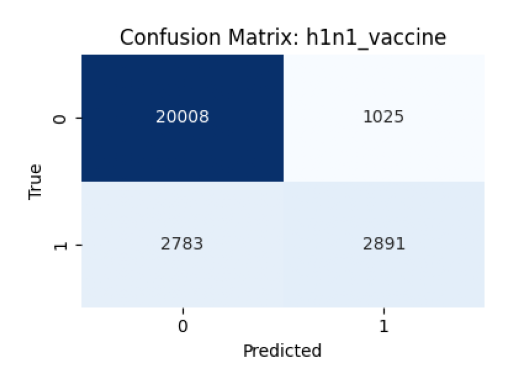

h1n1_vaccine (baseline) normalized


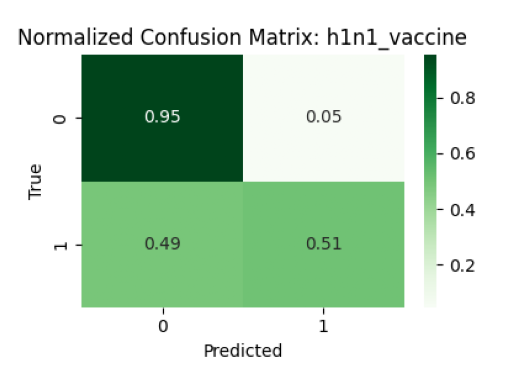

Missing: confusion_matrix_h1n1_vaccine_tuned.png
Missing: confusion_matrix_h1n1_vaccine_tuned_normalized.png
seasonal_vaccine (baseline) counts


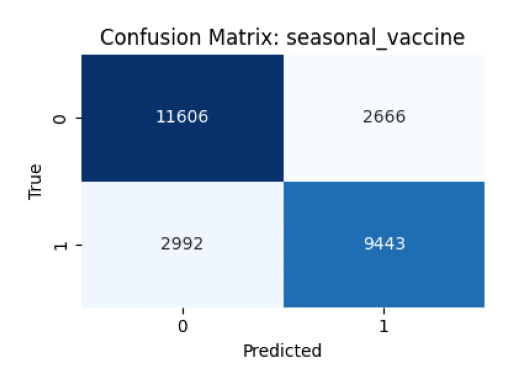

seasonal_vaccine (baseline) normalized


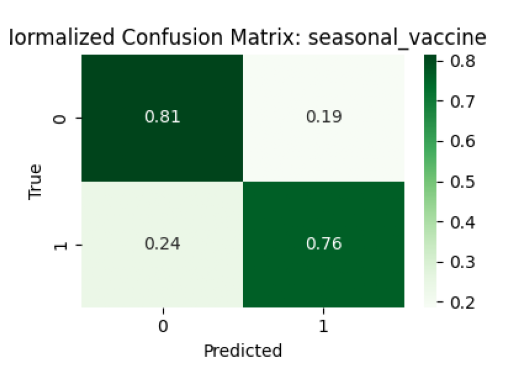

Missing: confusion_matrix_seasonal_vaccine_tuned.png
Missing: confusion_matrix_seasonal_vaccine_tuned_normalized.png


In [3]:
import matplotlib.pyplot as plt

for label in ["h1n1_vaccine", "seasonal_vaccine"]:
    for suffix in ["", "_normalized", "_tuned", "_tuned_normalized"]:
        img_path = ARTIFACTS / f"confusion_matrix_{label}{suffix}.png"
        if img_path.exists():
            title = f"{label} {'(tuned)' if 'tuned' in suffix else '(baseline)'} {'normalized' if 'normalized' in suffix else 'counts'}"
            print(title)
            img = plt.imread(img_path)
            plt.imshow(img)
            plt.axis("off")
            plt.show()
        else:
            print(f"Missing: {img_path.name}")

In [4]:
import pandas as pd

rows = []
for label in TARGET_COLS:
    base = baseline_results[label]
    tuned = tuned_results[label]["metrics"]
    rows.append({
        "Target": label,
        "Baseline_F1": base["f1"],
        "Tuned_F1": tuned["f1"],
        "Baseline_Precision": base["precision"],
        "Tuned_Precision": tuned["precision"],
        "Baseline_Recall": base["recall"],
        "Tuned_Recall": tuned["recall"],
        "Baseline_ROC_AUC": base["roc_auc"],
        "Tuned_ROC_AUC": tuned["roc_auc"],
    })

df_compare = pd.DataFrame(rows)
for c in df_compare.columns:
    if c != "Target":
        df_compare[c] = pd.to_numeric(df_compare[c], errors="coerce")
df_compare = df_compare.fillna(0.0)
df_compare["ΔF1"] = df_compare["Tuned_F1"] - df_compare["Baseline_F1"]

print("\n=== Baseline vs Tuned ===")
print(df_compare.round(3).to_string(index=False))



=== Baseline vs Tuned ===
          Target  Baseline_F1  Tuned_F1  Baseline_Precision  Tuned_Precision  Baseline_Recall  Tuned_Recall  Baseline_ROC_AUC  Tuned_ROC_AUC   ΔF1
    h1n1_vaccine        0.603     0.791               0.738            0.694            0.510         0.919             0.870          0.966 0.188
seasonal_vaccine        0.769     0.846               0.780            0.856            0.759         0.836             0.864          0.937 0.077


**Creating a file for submission**

In [5]:
from joblib import load
import pandas as pd
from pathlib import Path

# Load models
model_h1n1 = load("artifacts_lgbm/h1n1_vaccine_tuned_model.pkl")
model_seas = load("artifacts_lgbm/seasonal_vaccine_tuned_model.pkl")

# Load test data
test_df = pd.read_csv("../data/processed/test_fe_full.csv")
respondent_id = test_df["respondent_id"]
X_test = test_df.drop(columns=["respondent_id", "Unnamed: 0"], errors="ignore")

# Predict probabilities
pred_h1n1 = model_h1n1.predict_proba(X_test)[:, 1]
pred_seas = model_seas.predict_proba(X_test)[:, 1]

submission = pd.DataFrame({
    "respondent_id": respondent_id,
    "h1n1_vaccine": pred_h1n1,
    "seasonal_vaccine": pred_seas
})

submission.to_csv("../submission.csv", index=False)
submission.head()

,respondent_id,h1n1_vaccine,seasonal_vaccine
0,26707,0.246029,0.225712
1,26708,0.153459,0.025124
2,26709,0.394888,0.704950
3,26710,0.897357,0.887429
4,26711,0.527989,0.558814


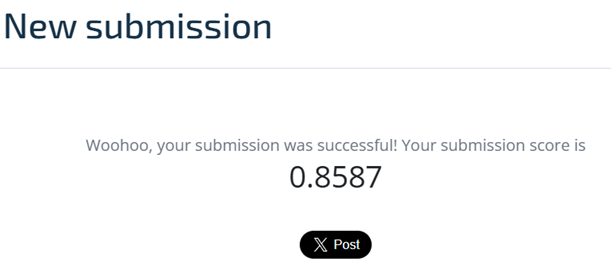

In [7]:
from IPython.display import Image
Image("../Submission_result(LightGBM).png")
